<div style="display: flex; justify-content: space-between;">
<div style="text-align: left; display: inline-block;" align="left"><b>Tepper School of Business </b></div>
<div style="text-align: right; display: inline-block;" align="right"><i>Dennis Epple</i></div>
</div>
<hr>
<div style="display: flex; justify-content: space-between;">
<div style="text-align: left" align="left">Statistics and Decision Making (45-752)</div>
<div style="text-align: right" align="right"><i>2025</i></div>
</div>

# Assignment 6 Solution
This assignment gives you practice with analysis of time series data, applying logit, and analyzing a model with lagged variables.

In [ ]:
# This command installs tprstats from its GitHub repo. You only need to run this command once, when start the notebook.
#!pip install git+https://github.com/dnepple/tprstats-python@colab

# stress test to see if this is a good solution to problem of installing tprstats
try:
    import tprstats
except ImportError as e:
  !pip install git+https://github.com/dnepple/tprstats-python@colab
  import tprstats

In [ ]:
# ====== Data Setup ======
import os, urllib.request

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

GITHUB_RAW = "https://raw.githubusercontent.com/mhnam/statistical-decision-making/main/data"

# Set working directory so that data/ is directly accessible
if IN_COLAB:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
    except Exception:
        pass
    if os.path.exists("/content/drive/MyDrive/SDM/data"):
        os.chdir("/content/drive/MyDrive/SDM")
    else:
        os.makedirs("data", exist_ok=True)
else:
    for parent in [".", "..", "../.."]:
        if os.path.exists(os.path.join(parent, "data")):
            if parent != ".":
                os.chdir(parent)
            break
    else:
        os.makedirs("data", exist_ok=True)

# Download any missing data files from GitHub
def _download(filename):
    path = f"data/{filename}"
    if not os.path.exists(path):
        print(f"Downloading {filename}...")
        urllib.request.urlretrieve(f"{GITHUB_RAW}/{filename}", path)

for f in ["Coffee_Data_Assign6.xlsx", "AWE_East.xlsx", "Order_Shipment.xlsx"]:
    _download(f)

print(f"Working directory: {os.getcwd()}")

Import the following packages that are needed for this assignment.

In [2]:
import numpy
import pandas
from scipy import stats
import matplotlib.pyplot as plt

## Exercise 1: Estimating a Model Using Time Series data
In Slide Set 10, we studied a model of coffee demand. We estimated a model linear in variables (e.g., no logarithms or other transformations of the variables). We studied the model and found that the Ramsey test gave relatively high p-values favorable to both the linear  functional form and the model with variables in log form. The file Coffee_Data_Assign6.xlsx has the data we studied in Slide Set 10. In addition, I have added another column of data for the price index for the real price of tea, named rptea. Import the data fle using the command below.

We will be looking at data after 1966. Hence, the additional query command.

In [3]:
# Import Coffee Data and select for years after 1966
Coffee_Data = pandas.read_excel("data/Coffee_Data_Assign6.xlsx").query("year>1966")

In our class, I mentioned that it would be natural to investigate whether tea is a substitute for coffee. In the past when I looked for a  price index for tea, I found data that only covered part of the period of our sample. I did a search and found that such an index is now available. The index is for "Tea in Consumer Packages Excluding Canned Ice Tea". Note that this is the producer price index for tea, but the consumer price index for tea is likely to closely follow the producer price index. Below  I have placed the commands for doing  a plot with year on the horizontal axis and rpcofe, rpcarb, rpcinc on the vertical axis. Add a curve for rptea with color orange. Do you agree that the real price of tea has not changed much over time?

Do a plot with year on the horizontal axis and rpcofe, rpcinc, rpcarb, and rptea on the vertical axis. To help you get started, I have created a plot with all but the rptea variable. Add rptea with color orange. Do the plot. Then further below you will find the graph with the real price of tea added to compare with your plot.

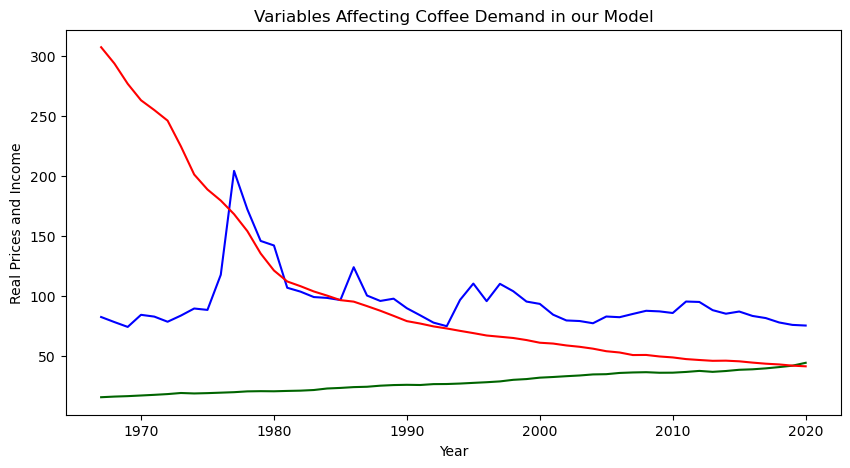

In [4]:
# Plot coffee price, per capita income, and real prices of coffee and tea
plt.figure(figsize=(10, 5))
plt.title("Variables Affecting Coffee Demand in our Model")
plt.xlabel("Year")
plt.ylabel("Real Prices and Income")
plt.plot(Coffee_Data["year"], Coffee_Data["rpcofe"], color="blue")
plt.plot(Coffee_Data["year"], Coffee_Data["rpcinc"], color="darkgreen")
plt.plot(Coffee_Data["year"], Coffee_Data["rptea"], color="red")

### Question 1b
Estimate a model with cons as the dependent variable and rpcofe, rpcinc, and rptea as independet variables. Report your coeﬃcient for rpcofe.

### Question 1c
Do all of the coefficients have the right algebraic signs?

### Question 1d

Are all of the coefficients significant at the 5% level?

### Question 1e 

Calculate the scaled coefficients and interpret the standardized coefficient of rptea.

### Question 1d

Test the functional form and report your conclusion.

### Question 1e

Now estimate the model with variables in log form and interpret the coefficient of the logarithm of rpcinc.

### Question 1f

Are all of the coefficients other than the intercept significant at the 5% level?

### Question 1g

Do the coefficients of the three independent variables all have the right algebraic signs?

### Question 1h

Test the functional form and report your conclusion.

### Question 1i
Estimate the above model allowing for first-order autocorrelation of the residuals. Report your estimated correlation coeﬃcient.

### Question 1j
Based on the above analyses, do you think the model linear in variables or the model in logs is most
appropriate for this application? One or two sentences is suﬃcient.

### Question 1k

The graph below adds the real price of tea. Has the real price of tea changed much over time?

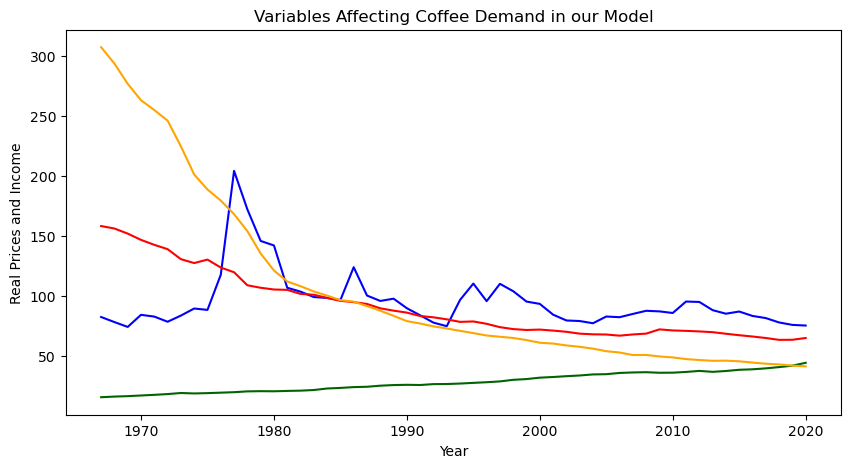

In [12]:
# Plot coffee price, per capita income, price of carbonated beverages
plt.figure(figsize=(10, 5))
plt.title("Variables Affecting Coffee Demand in our Model")
plt.xlabel("Year")
plt.ylabel("Real Prices and Income")
plt.plot(Coffee_Data["year"], Coffee_Data["rpcofe"], color="blue")
plt.plot(Coffee_Data["year"], Coffee_Data["rpcinc"], color="darkgreen")
plt.plot(Coffee_Data["year"], Coffee_Data["rpcarb"], color="red")
plt.plot(Coffee_Data["year"], Coffee_Data["rptea"], color="orange")

### Question 1l
Estimate a regression for coﬀee consumption, cons, with explanatory variables rpcofe, rpcinc, rpcarb, rptea. Report your coeﬃcient for rptea.


### Question 1m
Does the coeﬃcient of rptea have the correct algebraic sign for a beverage that is a substitute for coﬀee?

### Question 1n
Is the coeﬃcient of rptea significant at the 1% level?


### Question 1o
Using the scaled coeﬃcients command, calculate scaled coeﬃcients for the model in part (j). Report and interpret the price elasticity of coﬀee consumption with respect to the price of tea.

## Exercise 2: A logit application combining experimentation, estimation, and optimization

In Note Set 9, we analyzed the optimal warranty price for the AWE store on the west side of the metropolitan area that it serves. AWE found the results of the experiment in the west side store to have been quite valuable in increasing the profit from its refrigerator warranties.  Hence, AWE has conducted a similar experiment for its east side store. The results are in file AWE_East.xlsx. This file contains results for1,000 customers from the East store. The variable X contains discount offered each individual in each the sample. Variable Y_E is an indicator for whether refrigerator buyers in the East store purchased the warranty when offered discount.  

In [15]:
AWE_East = pandas.read_excel("data/AWE_East.xlsx")

### Question 2a
Estimate a logit model of Y_E vs X and name the model AWE_logit. Report your coefficients.

### Question 2b
Using the marginal_effects command, calculate and interpret the marginal effect of X.

### Question 2c
Using your estimated model, write the Python command to calculate the predicted probability of purchase if the warranty discount is 33. Report your result.

### Question 2d
Now investigate the optimal warranty for AWE.  

- AWE has been pricing its warranty at \\$300.
- If AWE adopts a discount of X%, its price will be 300*(1-X/100).
- Hence, its revenue from each warranty sold will be 300*(1-X/100).
- **AWE has become more efficient in doing repairs. As a result, the present value of the cost of servicing a warranty over five years has fallen from \\$120 to \\$110.**  

Write the formula for the expected profit per customer with discount X letting p(X) denote the probability of purchase at discount X.

### Question 2e
Create a range of values of the discount from 0 to 50 in increments of 1 percentage point using the arange() command and name the resulting variable discounts.  

Reminder: Python starts counting from 0.

### Question 2f

Using the logit model, calculate predicted purchase probability for each value of discounts. Note that this corresponds to function p(X) above:

### Question 2g
To see the relationship of purchase probability to discount, do a plot with the predicted purchase probabilities on the vertical axis and discounts on the horizontal axis.

### Question 2h
Next, calculate expected profit for each value of discount and name the result profit. Remember that the beginning of this question reported that the cost of servicing a warranty is 110 dollars.

### Question 2i
Plot the result using the command below. From looking at the plot, roughly what percent discount will maximize profit?

### Question 2j
Now, determine more precisely which discount will maximize profit. Using the appropriate command, determine which observation has maximum profit:

### Question 2k
Find the discount that maximizes profit. Report the optimal percent discount and the expected profit per warranty at that discount.


### Question 2l
Calculate and report the price of the warranty at the optimal discount.

## Exercise 3
Suppose that you find yourself as an intern for a manufacturing company during the coming summer.  One day you happen to have lunch with your supervisor.  He tells you he has been with the company only a few weeks, and he is disappointed with the information that is available about timeliness with which Orders have been filled over the past several years.  He says that the information system retains information about how many Orders were received each week and how many units of the product were shipped each week, but no information is retained about the time between when an order is placed and when the product for that order is shipped. He says “I wish I knew what proportion of Orders were shipped the week they were placed, what proportion were shipped the week after they were placed, what proportion were shipped two weeks after they were placed, etc.”  You tell him that you will be glad to provide him the answer if he gives you the data that are available.  He says that, unless you are a magician, he does not see how you can do it, but he knows you were trained at Tepper, so he promptly gives you the data.  

The data in file Order_Shipment.xlsx. The variables are weekly Orders (Orders) received and shipments (Ship) for a period of 208 weeks. In the notation below, Orders(-1) denotes orders shipped one week after they were received.  

$$Ship = \beta_0 + \beta_1 Orders + \beta_2 Orders(-1) + \beta_3 Orders(-2)+ \beta_4 Orders(-3) + \epsilon$$

In Python formula, Orders(-1) is written lag(Orders,1).

### Question 3a(\*)
Import Order_Shipment.xlsx. Estimate the above model. You can copy the command below and past it into your Python script. Your intercept should be -87.166. Report your t-statistic for the coefficient of Orders. Reminder, this is a time series.

In [27]:
Order_Shipment = pandas.read_excel("data/Order_Shipment.xlsx")

### Question 3b(\*)
Test the adequacy of this functional form.

### Question 3c
At your lunch conversation, your supervisor said he would like to know the proportion of Orders that where shipped the week after they were received. Using your regression from part (a) please provide the answer for your supervisor. Hint lag(Orders(1))

### Question 3d
Your supervisor asks you what proportion of Orders were shipped within one week after they were received.

### Question 3e
Using a significance level  of .05, test the null hypothesis that β4=0. Report your p-value and your conclusion.


### Question 3f
Test the null hypothesis that the intercept is zero and 40% of orders were shipped the week they were received using a 5% significance level.  Write the Python command you used and report your test result, and your conclusion.

### Question 3g
Suppose the company promises customers that Orders will ship by the end of two weeks after they are received. What would this imply about the coefficients of the order variables in the model? Please state your answers in terms of the β coefficients in the model. Explain briefly.

### Question 3h
Test the null hypothesis that the intercept is zero and 99% of orders were shipped within two weeks after they were received received using a 5% significance level.  Write the Python command you used and report your test result, and your conclusion.